In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
import pickle
import warnings
warnings.filterwarnings('ignore')

print('Setup completed successfully')

Setup completed successfully


In [4]:
# Load data
filename = './train.csv'
data = pd.read_csv(filename)
print(f"Dataset shape: {data.shape}")
data.head()

Dataset shape: (18524, 9)


,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert
3,3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert



=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18524 entries, 0 to 18523
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         18524 non-null  int64  
 1   Time_spent_Alone           17334 non-null  float64
 2   Stage_fear                 16631 non-null  object 
 3   Social_event_attendance    17344 non-null  float64
 4   Going_outside              17058 non-null  float64
 5   Drained_after_socializing  17375 non-null  object 
 6   Friends_circle_size        17470 non-null  float64
 7   Post_frequency             17260 non-null  float64
 8   Personality                18524 non-null  object 
dtypes: float64(5), int64(1), object(3)
memory usage: 1.3+ MB

=== Missing Values ===
id                              0
Time_spent_Alone             1190
Stage_fear                   1893
Social_event_attendance      1180
Going_outside                146

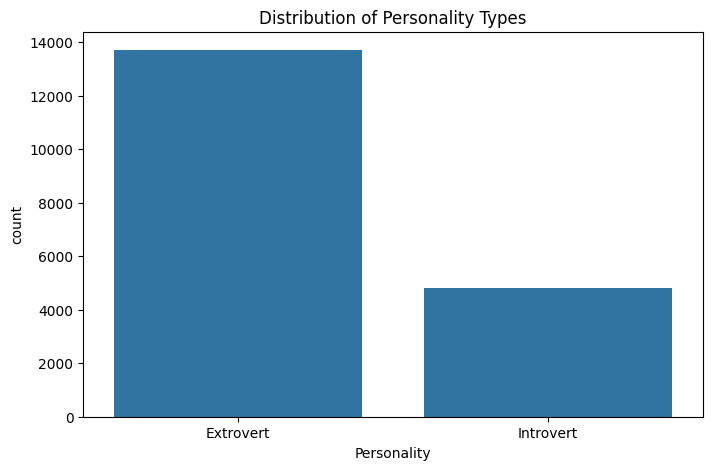

In [5]:
# Exploratory Data Analysis (EDA)
print("\n=== Dataset Info ===")
data.info()

print("\n=== Missing Values ===")
print(data.isnull().sum())

print("\n=== Target Variable Distribution ===")
print(data["Personality"].value_counts())
print(f"\nProportions: {data['Personality'].value_counts(normalize=True)}")

# Visualize target distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='Personality')
plt.title('Distribution of Personality Types')
plt.show()

In [6]:
# Encode categorical variables
data["Stage_fear"] = data["Stage_fear"].map({"Yes": 0, "No": 1})
data["Drained_after_socializing"] = data["Drained_after_socializing"].map({"Yes": 0, "No": 1})
data["Personality"] = data["Personality"].map({"Extrovert": 0, "Introvert": 1})

# Verify encoding
print("Encoding completed")
print(f"Stage_fear unique values: {data['Stage_fear'].unique()}")
print(f"Personality unique values: {data['Personality'].unique()}")

Encoding completed
Stage_fear unique values: [ 1.  0. nan]
Personality unique values: [0 1]


In [7]:
# Handle missing values with median
numeric_cols = data.select_dtypes(include=[np.number]).columns
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())
print(f"Missing values after imputation: {data.isnull().sum().sum()}")

Missing values after imputation: 0


In [8]:
# Feature Engineering (improved version)
data["social_score"] = (
    data["Social_event_attendance"] + 
    data["Going_outside"] + 
    data["Friends_circle_size"] + 
    data["Post_frequency"]
)

data["introvert_score"] = (
    data["Time_spent_Alone"] + 
    data["Drained_after_socializing"]
)

# Avoid division by zero
data["alone_vs_social"] = data["Time_spent_Alone"] / (data["Social_event_attendance"] + 1e-5)
data["friends_per_outing"] = data["Friends_circle_size"] / (data["Going_outside"] + 1e-5)

# Interaction features
data["fear_x_social"] = data["Stage_fear"] * data["Social_event_attendance"]
data["drained_x_outside"] = data["Drained_after_socializing"] * data["Going_outside"]

# Binned feature (only once!)
data["alone_bin"] = pd.cut(data["Time_spent_Alone"], bins=3, labels=[0, 1, 2])

print("Feature engineering completed")
print(f"New features added: {data.shape[1] - 9}")

Feature engineering completed
New features added: 7


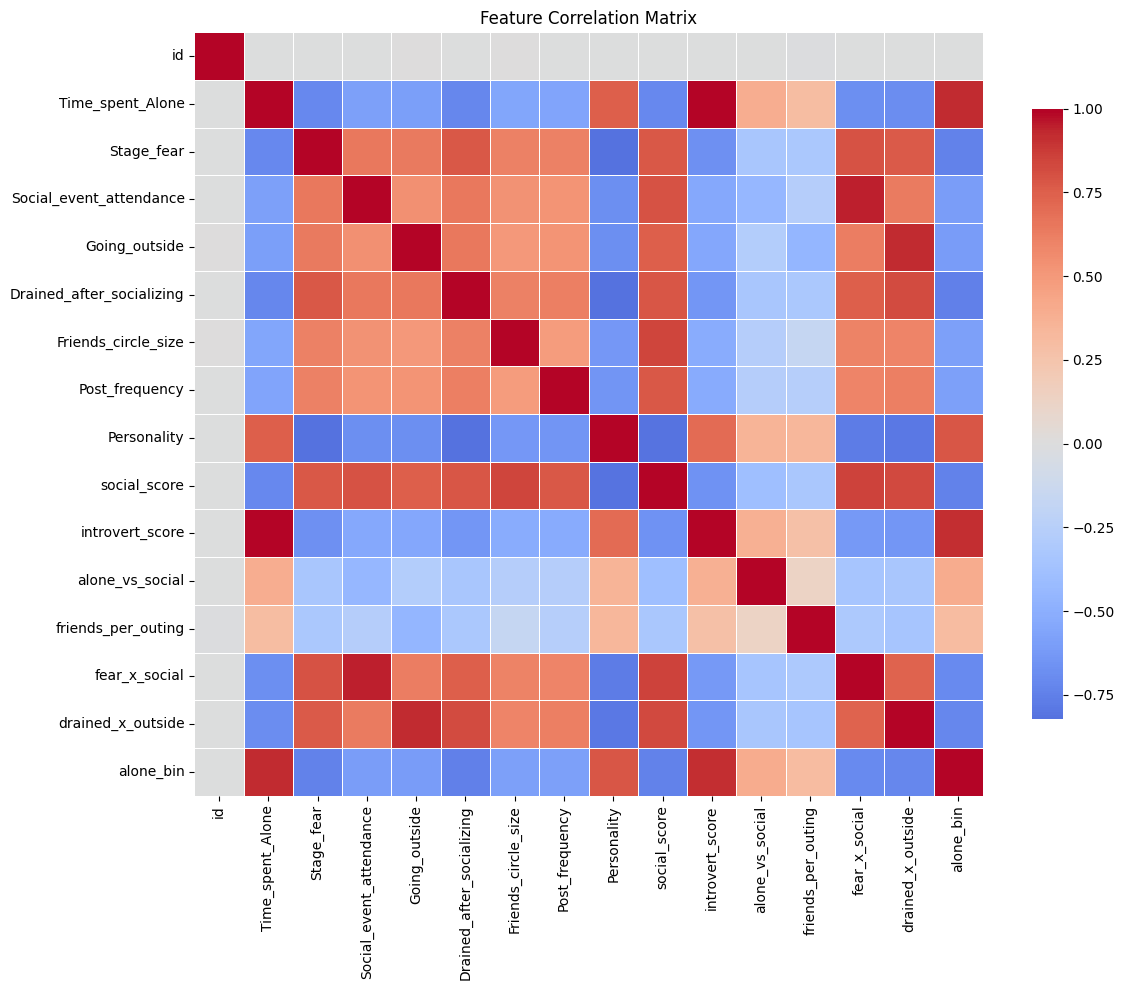


=== Top Correlations with Personality ===
Personality                  1.000000
alone_bin                    0.786051
Time_spent_Alone             0.750859
introvert_score              0.701916
alone_vs_social              0.354781
friends_per_outing           0.344892
id                           0.001475
Friends_circle_size         -0.634583
Post_frequency              -0.647048
Going_outside               -0.674389
Social_event_attendance     -0.674635
fear_x_social               -0.778353
drained_x_outside           -0.790140
social_score                -0.813689
Stage_fear                  -0.816959
Drained_after_socializing   -0.822843
Name: Personality, dtype: float64


In [9]:
# Correlation analysis
plt.figure(figsize=(12, 10))
corr_matrix = data.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, 
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Show top correlations with target
target_corr = corr_matrix['Personality'].sort_values(ascending=False)
print("\n=== Top Correlations with Personality ===")
print(target_corr)

In [10]:
# Prepare features and target
y = data["Personality"]
X = data.drop(["Personality", "id"], axis=1)  # Keep all engineered features

# Convert categorical to numeric for alone_bin
X = pd.get_dummies(X, columns=['alone_bin'], drop_first=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Target distribution in train: {y_train.value_counts(normalize=True)}")

Training set size: (12966, 15)
Test set size: (5558, 15)
Target distribution in train: Personality
0    0.73955
1    0.26045
Name: proportion, dtype: float64


In [11]:
# Logistic Regression with Cross-Validation and Scaling
print("=== Logistic Regression ===")

# Create pipeline with scaling
log_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Cross-validation
cv_scores = cross_val_score(log_reg_pipeline, X_train, y_train, cv=5, scoring='f1')
print(f"Cross-validation F1 scores: {cv_scores}")
print(f"Mean CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Train and evaluate
log_reg_pipeline.fit(X_train, y_train)
preds = log_reg_pipeline.predict(X_test)

print(f"\nTest set Accuracy: {accuracy_score(y_test, preds):.4f}")
print(f"Test set F1: {f1_score(y_test, preds):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, preds, target_names=['Extrovert', 'Introvert']))

=== Logistic Regression ===
Cross-validation F1 scores: [0.93693694 0.93244246 0.93731343 0.94161677 0.94013304]
Mean CV F1: 0.9377 (+/- 0.0063)

Test set Accuracy: 0.9705
Test set F1: 0.9433

Classification Report:
              precision    recall  f1-score   support

   Extrovert       0.98      0.98      0.98      4110
   Introvert       0.95      0.94      0.94      1448

    accuracy                           0.97      5558
   macro avg       0.96      0.96      0.96      5558
weighted avg       0.97      0.97      0.97      5558



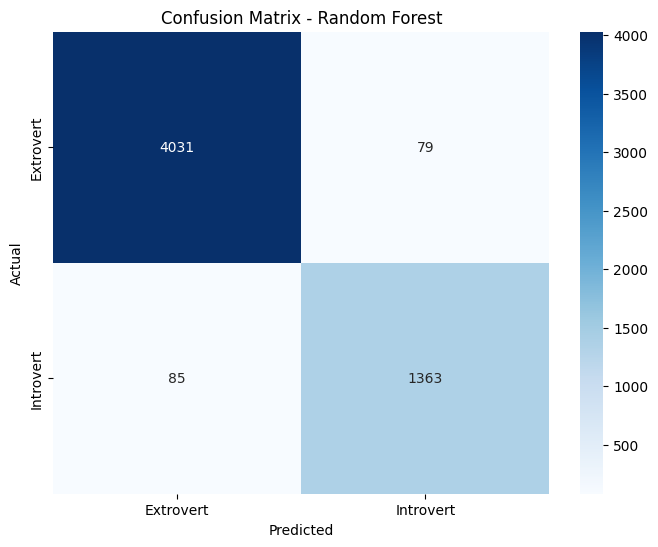

In [12]:
# Confusion Matrix for best model
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Extrovert', 'Introvert'],
            yticklabels=['Extrovert', 'Introvert'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

=== Random Forest Classifier ===
Performing grid search...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1 score: 0.9378

Test set Accuracy: 0.9710
Test set F1: 0.9444

Classification Report:
              precision    recall  f1-score   support

   Extrovert       0.98      0.98      0.98      4110
   Introvert       0.94      0.94      0.94      1448

    accuracy                           0.97      5558
   macro avg       0.96      0.96      0.96      5558
weighted avg       0.97      0.97      0.97      5558


=== Top 10 Most Important Features ===
                      feature  importance
12          drained_x_outside    0.255481
7                social_score    0.153774
11              fear_x_social    0.134400
9             alone_vs_social    0.128227
4   Drained_after_socializing    0.078924
1                  Stage_fear    0.068703
0            Time_

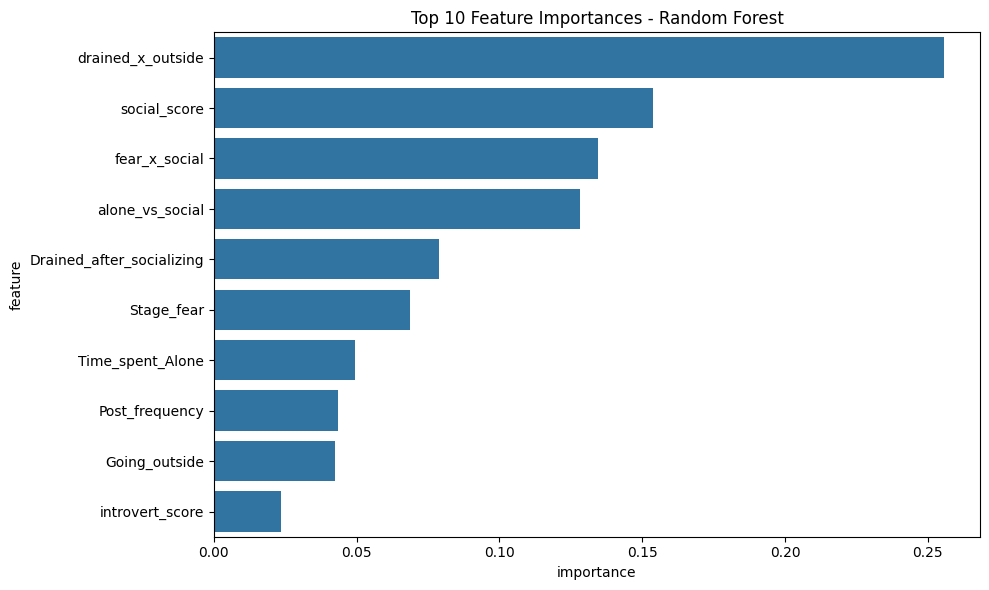

In [13]:
# Random Forest with Hyperparameter Tuning
print("=== Random Forest Classifier ===")

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid search with cross-validation
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(
    rf_base, param_grid, cv=5, 
    scoring='f1', n_jobs=-1, verbose=1
)

print("Performing grid search...")
grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV F1 score: {grid_search.best_score_:.4f}")

# Evaluate best model
best_rf = grid_search.best_estimator_
preds = best_rf.predict(X_test)

print(f"\nTest set Accuracy: {accuracy_score(y_test, preds):.4f}")
print(f"Test set F1: {f1_score(y_test, preds):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, preds, target_names=['Extrovert', 'Introvert']))

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Top 10 Most Important Features ===")
print(feature_importance.head(10))

# Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature')
plt.title('Top 10 Feature Importances - Random Forest')
plt.tight_layout()
plt.show()

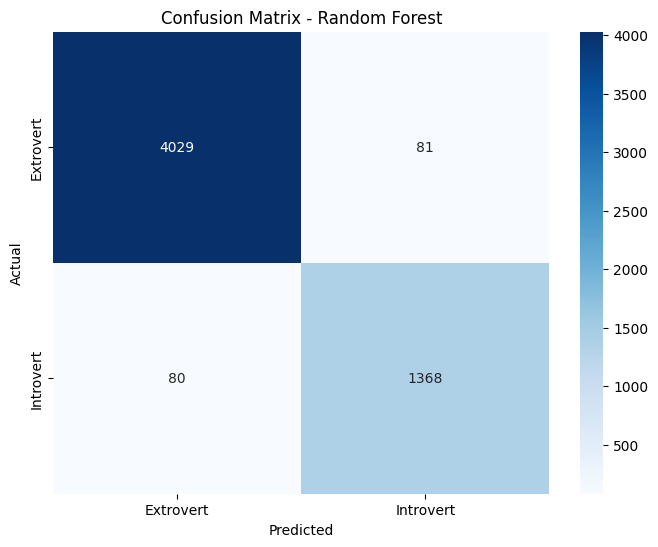

In [14]:
# Confusion Matrix for best model
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Extrovert', 'Introvert'],
            yticklabels=['Extrovert', 'Introvert'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [15]:
# Best parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
model = RandomForestClassifier(max_depth=10, min_samples_leaf=4, min_samples_split=2, n_estimators=100)
model.fit(X_train, y_train)
predict = model.predict(X_test)
print(classification_report(y_test, predict, target_names=['Extrovert', 'Introvert']))

              precision    recall  f1-score   support

   Extrovert       0.98      0.98      0.98      4110
   Introvert       0.94      0.94      0.94      1448

    accuracy                           0.97      5558
   macro avg       0.96      0.96      0.96      5558
weighted avg       0.97      0.97      0.97      5558



In [17]:
with open("introvert.learn", "wb") as file:
    pickle.dump(model, file)